In [1]:
#Installing the libraries
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib
!pip install sklearn.cluster
!pip install sklearn.preprocessing

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
ERROR: Could not find a version that satisfies the requirement sklearn.cluster (from versions: none)
ERROR: No matching distribution found for sklearn.cluster
Defaulting to user installation because normal site-packages is not writeable
ERROR: Could not find a version that satisfies the requirement sklearn.preprocessing (from versions: none)
ERROR: No matching distribution found for sklearn.preprocessing


In [2]:
#Reading in DataFrames and Cleaning Data
df_greenspace = pd.read_csv('shared_data_read_only/Greenspace.csv')
df_walkability = pd.read_csv('shared_data_read_only/Walkability.csv')
df_rentdata = pd.read_csv('shared_data_read_only/HUD_Rent_Data.csv')
df_econ = pd.read_csv('shared_data_read_only/2021_CBP_NAICS_ECON_DATA.csv')
df_school_valueadded = pd.read_excel('shared_data_read_only/District_Value_Added_Ranking.xlsx')

In [3]:
df_rent_prop = pd.read_excel('Team-13/rent_data_feature_proportions.xlsx')

In [4]:
df_school_variance = pd.read_excel('Team-13/Education Variance Per Zip Code.xlsx')

In [5]:
df_school_variance['Zip Code'] = df_school_variance['Zip Code'].astype(str)

In [6]:
df_rent_prop['Unnamed: 0'] = df_rent_prop['Unnamed: 0'].astype(str)

In [7]:
df_zip = pd.read_csv('shared_data_read_only/geography_mappings/ZIP_TRACT_122021.csv')

In [8]:
df_econ = pd.read_csv('shared_data_read_only/2021_CBP_NAICS_ECON_DATA.csv')

In [9]:
df_econ = df_econ[['ZIP_CODE', 'NAICS2017_LABEL']]

In [10]:
df2 = df_econ.copy() 
df2 = df2.groupby(['ZIP_CODE']).count()
df2 = df2.sort_values('NAICS2017_LABEL', ascending = True)
df2 = df2.rename(columns={'NAICS2017_LABEL': "Total Establishments"})
df2

,Total Establishments
ZIP_CODE,
45218,1
45623,1
44629,1
44628,1
45657,1
...,...
44122,340
45069,355
45202,360


In [11]:
#medical services (physical health) 
df3 = df_econ.copy() 
filter1 = df3['NAICS2017_LABEL'] == 'Offices of physicians (except mental health specialists)'
filter2 = df3['NAICS2017_LABEL'] == 'Offices of dentists'
filter3 = df3['NAICS2017_LABEL'] == 'Offices of chiropractors'
filter4 = df3['NAICS2017_LABEL'] == 'Offices of physical, occupational and speech therapists, and audiologists'
df3 = df3.where(filter1 | filter2 | filter3 | filter4)
df3 = df3.dropna()
df3 = df3.groupby(['ZIP_CODE']).count()
df3 = df3.sort_values('NAICS2017_LABEL', ascending = True)
df3 = df3.rename(columns={'NAICS2017_LABEL': 'Medical Service Establishments'})
df_econ_column = df3.copy()

In [12]:
df_econ_column.head()

,Medical Service Establishments
ZIP_CODE,
43793.0,1
44040.0,1
44137.0,1
43515.0,1
44273.0,1


In [13]:
df_greenspace.head()

,Census_Block_Group,Greenspace_Pct,Greenspace_Per_Cap
0,484530001011,78.599998,893.59
1,484530001012,67.169998,587.18
2,484530001013,61.180000,433.15
3,484530001021,82.650002,1385.59
4,484530001022,74.889999,2273.05


In [14]:
df_greenspace.dtypes

Census_Block_Group      int64
Greenspace_Pct        float64
Greenspace_Per_Cap    float64
dtype: object

In [15]:
#Creating column for Census Tract
df_greenspace['Census_Block_Group'] = df_greenspace['Census_Block_Group'].astype(str)
df_greenspace['Tract'] = df_greenspace['Census_Block_Group'].str[5:-1]

In [16]:
df_walkability.head()

,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,CBSA,CBSA_Name,NatWalkInd
0,48,113,7825,4,19100.0,"Dallas-Fort Worth-Arlington, TX",14.000000
1,48,113,7825,2,19100.0,"Dallas-Fort Worth-Arlington, TX",10.833333
2,48,113,7825,3,19100.0,"Dallas-Fort Worth-Arlington, TX",8.333333
3,48,113,7824,1,19100.0,"Dallas-Fort Worth-Arlington, TX",15.666667
4,48,113,7824,2,19100.0,"Dallas-Fort Worth-Arlington, TX",10.166667


In [17]:
#Filling in Tract column with leading zeroes
df_walkability['TRACTCE'] = df_walkability['TRACTCE'].astype(str).str.zfill(6)

In [18]:
#Combining Walkability and Greenspace Columns
greenspace_and_walkability = df_walkability.merge(df_greenspace, left_on='TRACTCE', right_on='Tract', how='inner')

In [19]:
greenspace_and_walkability.head()

,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,CBSA,CBSA_Name,NatWalkInd,Census_Block_Group,Greenspace_Pct,Greenspace_Per_Cap,Tract
0,48,113,009301,2,19100.0,"Dallas-Fort Worth-Arlington, TX",8.0,410510093011,57.000000,226.40,009301
1,48,113,009301,2,19100.0,"Dallas-Fort Worth-Arlington, TX",8.0,410510093012,56.970001,177.55,009301
2,48,113,009301,2,19100.0,"Dallas-Fort Worth-Arlington, TX",8.0,410510093013,43.259998,71.04,009301
3,48,113,009301,2,19100.0,"Dallas-Fort Worth-Arlington, TX",8.0,110010093011,54.189999,171.00,009301
4,48,113,009301,2,19100.0,"Dallas-Fort Worth-Arlington, TX",8.0,110010093012,43.330002,151.00,009301


In [20]:
#Filtering for Ohio
greenspace_and_walkability = greenspace_and_walkability.loc[greenspace_and_walkability['STATEFP'] == 39]

In [21]:
greenspace_and_walkability['CITY'] = greenspace_and_walkability['CBSA_Name'].str.split(',').str[0]

In [22]:
# Calculate the mean 'NatWalkInd' for each 'CITY'
city_walkability_mean = greenspace_and_walkability.groupby('CITY')['NatWalkInd'].mean().reset_index()

# Merge the calculated means back into the original DataFrame based on 'CITY'
greenspace_and_walkability = greenspace_and_walkability.merge(city_walkability_mean, on='CITY', suffixes=('', '_mean'))

# Rename the new column to a meaningful name
greenspace_and_walkability.rename(columns={'NatWalkInd_mean': 'Mean_NatWalkInd'}, inplace=True)

In [23]:
# Calculate the mean 'NatWalkInd' for each 'CITY'
city_greenspace_mean = greenspace_and_walkability.groupby('CITY')['Greenspace_Pct'].mean().reset_index()

# Merge the calculated means back into the original DataFrame based on 'CITY'
greenspace_and_walkability = greenspace_and_walkability.merge(city_greenspace_mean, on='CITY', suffixes=('', '_mean'))


In [24]:
#Mapping the disparity metrics onto the appropriate cities
greenspace_and_walkability['Greenspace'] = greenspace_and_walkability['CITY'].map(city_walkability_mean['NatWalkInd'])

In [25]:
greenspace_and_walkability.tail()

,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,CBSA,CBSA_Name,NatWalkInd,Census_Block_Group,Greenspace_Pct,Greenspace_Per_Cap,Tract,CITY,Mean_NatWalkInd,Greenspace_Pct_mean,Greenspace
76670,39,99,801600,5,49660.0,"Youngstown-Warren-Boardman, OH-PA",11.0,240338016002,43.430000,93.0,801600,Youngstown-Warren-Boardman,6.609559,54.673966,NaN
76671,39,99,801600,5,49660.0,"Youngstown-Warren-Boardman, OH-PA",11.0,240338016003,55.639999,103.0,801600,Youngstown-Warren-Boardman,6.609559,54.673966,NaN
76672,39,99,801600,2,49660.0,"Youngstown-Warren-Boardman, OH-PA",6.0,240338016001,69.769997,131.0,801600,Youngstown-Warren-Boardman,6.609559,54.673966,NaN
76673,39,99,801600,2,49660.0,"Youngstown-Warren-Boardman, OH-PA",6.0,240338016002,43.430000,93.0,801600,Youngstown-Warren-Boardman,6.609559,54.673966,NaN
76674,39,99,801600,2,49660.0,"Youngstown-Warren-Boardman, OH-PA",6.0,240338016003,55.639999,103.0,801600,Youngstown-Warren-Boardman,6.609559,54.673966,NaN


In [26]:
df_zip['tract'] = df_zip['tract'].astype(str)
df_zip['Tract'] = df_zip['tract'].str[5:]

In [27]:
df_econ_column = df_econ_column.reset_index(drop=False)
df_econ_column.dtypes

ZIP_CODE                          float64
Medical Service Establishments      int64
dtype: object

In [28]:
df_econ_column['ZIP_CODE'] = df_econ_column['ZIP_CODE'].astype(str).str[:-2]

In [29]:
df_zip['zip'] = df_zip['zip'].astype(str)

In [30]:
df_zip.head()

,zip,tract,usps_zip_pref_city,usps_zip_pref_state,res_ratio,bus_ratio,oth_ratio,tot_ratio,Tract
0,683,72023830102,SAN GERMAN,PR,0.000791,0.001116,0.000000,0.000800,830102
1,683,72125840700,SAN GERMAN,PR,0.186219,0.370536,0.381643,0.201179,840700
2,683,72125840400,SAN GERMAN,PR,0.300451,0.187500,0.115942,0.290308,840400
3,683,72125840600,SAN GERMAN,PR,0.095325,0.007812,0.000000,0.088184,840600
4,683,72121960300,SAN GERMAN,PR,0.042402,0.002232,0.019324,0.039435,960300


In [31]:
greenspace_and_walkability.shape

(76675, 15)

In [32]:
#Complete DataFrame with all metrics
merged_econ_walk = df_econ_column.merge(df_zip, left_on='ZIP_CODE', right_on='zip', how='inner')
final_matched_df = merged_econ_walk.merge(greenspace_and_walkability, on='Tract', how='inner')

In [33]:
final_matched_df.drop_duplicates(inplace=True)

In [34]:
final_matched_df['Mean_NatWalkInd'].unique()

array([10.76492907, 11.12807661, 10.63802019, 10.81684922,  6.09505941,
        9.14766607, 11.96670122,  6.56697557,  6.22519252,  7.16991057,
        6.55352703,  5.89150867,  7.1689038 ,  6.8046859 ,  5.90620783,
        6.44891735,  5.97532781,  6.78677083,  6.71328725,  5.9533086 ,
        7.6372847 ,  5.7137823 ,  5.99395004,  6.60955928,  6.45244003,
        7.68767908,  7.46453333,  4.08928571])

In [35]:
final_matched_df.tail()

,ZIP_CODE,Medical Service Establishments,zip,tract,usps_zip_pref_city,usps_zip_pref_state,res_ratio,bus_ratio,oth_ratio,tot_ratio,...,CBSA,CBSA_Name,NatWalkInd,Census_Block_Group,Greenspace_Pct,Greenspace_Per_Cap,CITY,Mean_NatWalkInd,Greenspace_Pct_mean,Greenspace
465198,45069,18,45069,39017011109,WEST CHESTER,OH,0.095904,0.200075,0.107034,0.107196,...,17140.0,"Cincinnati, OH-KY-IN",9.166667,120570111092,88.173739,1286.303200,Cincinnati,11.128077,41.775884,NaN
465199,45069,18,45069,39017011109,WEST CHESTER,OH,0.095904,0.200075,0.107034,0.107196,...,17140.0,"Cincinnati, OH-KY-IN",8.500000,120570111091,87.656959,3976.359285,Cincinnati,11.128077,41.775884,NaN
465200,45069,18,45069,39017011109,WEST CHESTER,OH,0.095904,0.200075,0.107034,0.107196,...,17140.0,"Cincinnati, OH-KY-IN",8.500000,120570111092,88.173739,1286.303200,Cincinnati,11.128077,41.775884,NaN
465201,45069,18,45069,39017011109,WEST CHESTER,OH,0.095904,0.200075,0.107034,0.107196,...,17140.0,"Cincinnati, OH-KY-IN",4.666667,120570111091,87.656959,3976.359285,Cincinnati,11.128077,41.775884,NaN
465202,45069,18,45069,39017011109,WEST CHESTER,OH,0.095904,0.200075,0.107034,0.107196,...,17140.0,"Cincinnati, OH-KY-IN",4.666667,120570111092,88.173739,1286.303200,Cincinnati,11.128077,41.775884,NaN


In [36]:
# Calculate the mean 'bus_ratio' for each 'CITY'
city_bus_ratio_mean = final_matched_df.groupby('CITY')['bus_ratio'].mean().reset_index()

# Merge the calculated means back into the original DataFrame based on 'CITY'
final_matched_df = final_matched_df.merge(city_bus_ratio_mean, on='CITY', suffixes=('', '_mean'))

In [37]:
final_matched_df_2 = final_matched_df.merge(df_rent_prop, left_on='zip', right_on='Unnamed: 0')

In [38]:
final_matched_df_2 = final_matched_df_2.merge(df_school_variance, left_on='zip', right_on='Zip Code')

In [39]:
final_matched_df_2['Variance'].unique()

array([ 473.4650621 ,  117.02916601,  242.06856625,  160.39762671,
        150.19967477,  378.99716254,  428.24290845,  279.43358733,
        101.38949749,  270.48536255, 1000.        ,  217.67541823,
        199.92364993,  150.36476841,  375.82275583,   84.60027968,
         93.91749864,  180.36214362,  180.04387317,   52.47639713,
         71.78253934,  326.64953803])

In [134]:
#Making Similarity to Columbus Column
final_matched_df_2.loc[final_matched_df_2['CITY'] == 'Columbus']

# Select the metrics for similarity calculation
selected_metrics = ['Mean_NatWalkInd', 'Greenspace_Pct_mean', 'Medical Service Establishments',
                    'Proportion', 'Variance']

# Calculate the average difference for each city compared to 'Columbus'
final_matched_df_2['Avg_Diff'] = final_matched_df_2.apply(lambda row: row[selected_metrics].sub(final_matched_df_2[final_matched_df_2['CITY'] == 'Columbus'][selected_metrics].values[0]).abs().mean(), axis=1)

# Calculate similarity scores (inverse of average difference)
final_matched_df_2['Similarity_Score'] = 1 / (1 + final_matched_df_2['Avg_Diff'])

# Normalize similarity scores to obtain percent similarity
final_matched_df_2['Percent_Similarity'] = (final_matched_df_2['Similarity_Score'] / final_matched_df_2['Similarity_Score'].sum()) * 100

In [40]:
final_matched_df_2['Percent_Similarity']

KeyError: 'Percent_Similarity'

In [41]:
final_matched_df_2.drop_duplicates(inplace=True)

In [42]:
final_matched_df_2.head()

,ZIP_CODE,Medical Service Establishments,zip,tract,usps_zip_pref_city,usps_zip_pref_state,res_ratio,bus_ratio,oth_ratio,tot_ratio,...,Greenspace_Pct_mean,Greenspace,bus_ratio_mean,Unnamed: 0,0,1,Proportion,Zip Code,County,Variance
0,44040,1,44040,39035196300,GATES MILLS,OH,0.011923,0.016807,0.0,0.012155,...,51.924554,NaN,0.079683,44040,0,1,0,44040,Cuyahoga,473.465062
1,44040,1,44040,39035196300,GATES MILLS,OH,0.011923,0.016807,0.0,0.012155,...,51.924554,NaN,0.079683,44040,0,1,0,44040,Cuyahoga,473.465062
2,44040,1,44040,39035196300,GATES MILLS,OH,0.011923,0.016807,0.0,0.012155,...,51.924554,NaN,0.079683,44040,0,1,0,44040,Cuyahoga,473.465062
3,44040,1,44040,39035196300,GATES MILLS,OH,0.011923,0.016807,0.0,0.012155,...,51.924554,NaN,0.079683,44040,0,1,0,44040,Cuyahoga,473.465062
4,44040,1,44040,39035196300,GATES MILLS,OH,0.011923,0.016807,0.0,0.012155,...,51.924554,NaN,0.079683,44040,0,1,0,44040,Cuyahoga,473.465062


In [43]:
df_grouped = final_matched_df_2.groupby('CITY').mean()

In [46]:
df_grouped.head()

,Medical Service Establishments,res_ratio,bus_ratio,oth_ratio,tot_ratio,STATEFP,COUNTYFP,BLKGRPCE,CBSA,NatWalkInd,Greenspace_Pct,Greenspace_Per_Cap,Mean_NatWalkInd,Greenspace_Pct_mean,Greenspace,bus_ratio_mean,0,1,Proportion,Variance
CITY,,,,,,,,,,,,,,,,,,,,
Akron,6.415718,0.130658,0.117712,0.128907,0.129508,39.0,146.075171,2.351936,10420.0,7.352506,64.018194,1682.534223,7.464533,64.233546,NaN,0.121527,0.741458,1.197039,0.599089,303.441879
Ashtabula,6.150472,0.101064,0.118636,0.117651,0.102621,39.0,7.000000,2.798815,11780.0,5.523629,49.864367,-2669.034214,5.906208,51.099966,NaN,0.099967,0.968536,1.000000,0.968536,245.041649
Bellefontaine,3.784000,0.069604,0.042482,0.047737,0.064296,39.0,91.000000,2.349000,13340.0,5.423167,35.943611,-426.026005,5.975328,37.740189,NaN,0.095254,1.000000,1.000000,1.000000,512.862958
Canton-Massillon,5.584867,0.111745,0.123661,0.120422,0.113025,39.0,123.196319,2.570552,15940.0,7.515337,57.292863,1033.775051,7.687679,57.817650,NaN,0.123661,1.263804,1.325153,0.969325,413.146165
Cincinnati,5.624945,0.100801,0.098819,0.107631,0.100480,39.0,47.212980,2.272606,17140.0,11.849915,44.386141,-1388.043171,11.128077,41.775884,NaN,0.099797,0.870054,1.002020,0.868033,303.380534


In [49]:
final_matched_df_2.loc[final_matched_df_2['CITY'] == 'Youngstown-Warren-Boardman']

,ZIP_CODE,Medical Service Establishments,zip,tract,usps_zip_pref_city,usps_zip_pref_state,res_ratio,bus_ratio,oth_ratio,tot_ratio,...,Greenspace_Pct_mean,Greenspace,bus_ratio_mean,Unnamed: 0,0,1,Proportion,Zip Code,County,Variance
226208,44601,10,44601,39099813000,ALLIANCE,OH,0.04357,0.043816,0.004082,0.042489,...,54.673966,NaN,0.112719,44601,2,2,1,44601,Stark,326.649538
226209,44601,10,44601,39099813000,ALLIANCE,OH,0.04357,0.043816,0.004082,0.042489,...,54.673966,NaN,0.112719,44601,2,2,1,44601,Stark,326.649538
226210,44601,10,44601,39099813000,ALLIANCE,OH,0.04357,0.043816,0.004082,0.042489,...,54.673966,NaN,0.112719,44601,2,2,1,44601,Stark,326.649538
226211,44601,10,44601,39099813000,ALLIANCE,OH,0.04357,0.043816,0.004082,0.042489,...,54.673966,NaN,0.112719,44601,2,2,1,44601,Stark,326.649538
226212,44601,10,44601,39099813000,ALLIANCE,OH,0.04357,0.043816,0.004082,0.042489,...,54.673966,NaN,0.112719,44601,2,2,1,44601,Stark,326.649538
226213,44601,10,44601,39099813000,ALLIANCE,OH,0.04357,0.043816,0.004082,0.042489,...,54.673966,NaN,0.112719,44601,2,2,1,44601,Stark,326.649538
226214,44601,10,44601,39099813000,ALLIANCE,OH,0.04357,0.043816,0.004082,0.042489,...,54.673966,NaN,0.112719,44601,2,2,1,44601,Stark,326.649538
226215,44601,10,44601,39099813000,ALLIANCE,OH,0.04357,0.043816,0.004082,0.042489,...,54.673966,NaN,0.112719,44601,2,2,1,44601,Stark,326.649538
226216,44601,10,44601,39099813000,ALLIANCE,OH,0.04357,0.043816,0.004082,0.042489,...,54.673966,NaN,0.112719,44601,2,2,1,44601,Stark,326.649538
226217,44601,10,44601,39099813000,ALLIANCE,OH,0.04357,0.043816,0.004082,0.042489,...,54.673966,NaN,0.112719,44601,2,2,1,44601,Stark,326.649538


In [45]:
final_matched_df_2.head()

,ZIP_CODE,Medical Service Establishments,zip,tract,usps_zip_pref_city,usps_zip_pref_state,res_ratio,bus_ratio,oth_ratio,tot_ratio,...,Greenspace_Pct_mean,Greenspace,bus_ratio_mean,Unnamed: 0,0,1,Proportion,Zip Code,County,Variance
0,44040,1,44040,39035196300,GATES MILLS,OH,0.011923,0.016807,0.0,0.012155,...,51.924554,NaN,0.079683,44040,0,1,0,44040,Cuyahoga,473.465062
1,44040,1,44040,39035196300,GATES MILLS,OH,0.011923,0.016807,0.0,0.012155,...,51.924554,NaN,0.079683,44040,0,1,0,44040,Cuyahoga,473.465062
2,44040,1,44040,39035196300,GATES MILLS,OH,0.011923,0.016807,0.0,0.012155,...,51.924554,NaN,0.079683,44040,0,1,0,44040,Cuyahoga,473.465062
3,44040,1,44040,39035196300,GATES MILLS,OH,0.011923,0.016807,0.0,0.012155,...,51.924554,NaN,0.079683,44040,0,1,0,44040,Cuyahoga,473.465062
4,44040,1,44040,39035196300,GATES MILLS,OH,0.011923,0.016807,0.0,0.012155,...,51.924554,NaN,0.079683,44040,0,1,0,44040,Cuyahoga,473.465062


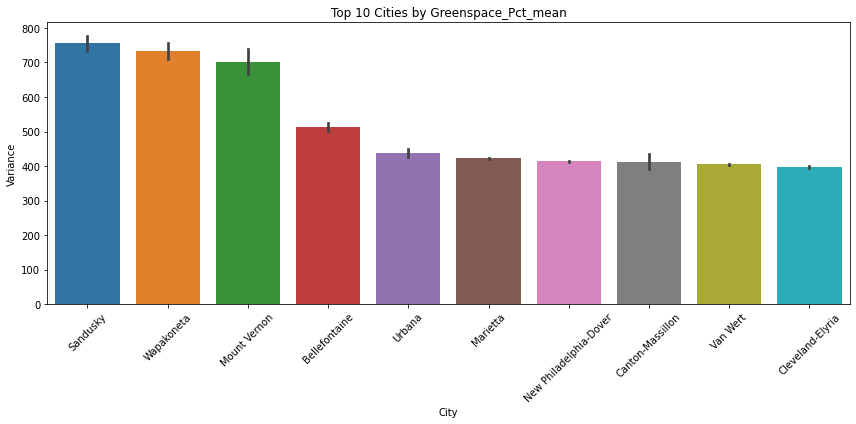

In [53]:
# Get the top 10 cities with the highest 'Greenspace_Pct_mean'
top_cities = final_matched_df_2.groupby('CITY')['Variance'].mean().nlargest(10).index

# Filter the DataFrame to include only the top 10 cities
df_top_10 = final_matched_df_2[final_matched_df_2['CITY'].isin(top_cities)]

# Create a bar chart using Seaborn
plt.figure(figsize=(12, 6))  # Set the figure size

# Use the 'x' parameter to specify the categorical variable ('CITY' in this case)
# and the 'y' parameter for the numerical variable ('Greenspace_Pct_mean')
sns.barplot(data=df_top_10, x='CITY', y='Variance', order=top_cities)

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45)

# Set plot labels and title
plt.xlabel('City')
plt.ylabel('Variance')
plt.title('Top 10 Cities by Greenspace_Pct_mean')

# Show the plot
plt.tight_layout()
plt.show()

In [50]:
df_top_10['CITY']

0         Cleveland-Elyria
1         Cleveland-Elyria
2         Cleveland-Elyria
3         Cleveland-Elyria
4         Cleveland-Elyria
                ...       
227578               Akron
227579               Akron
227580               Akron
227581               Akron
227582               Akron
Name: CITY, Length: 50862, dtype: object

In [69]:
# Selected metrics (dimensions) for clustering
selected_metrics = ['Mean_NatWalkInd', 'Greenspace_Pct_mean', 'Medical Service Establishments',
                    'Proportion', 'Variance']

# Create a new DataFrame with the selected metrics
X = df_grouped[selected_metrics]

# Normalize the feature matrix (if necessary)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

# Determine the number of clusters (you can specify this)
n_clusters = 7

# Create a K-Means clustering model
kmeans = KMeans(n_clusters=n_clusters, random_state=0)

# Fit the model to the data
kmeans.fit(scaled_data)

# Get cluster labels for each data point
cluster_labels = kmeans.labels_

# Add the cluster labels to the original DataFrame
df_grouped['Cluster'] = cluster_labels

# Print the resulting DataFrame with cluster labels
print(df_grouped)

                            Medical Service Establishments  res_ratio  \
CITY                                                                    
Akron                                             0.324347   0.711969   
Ashtabula                                         0.157274  -0.053699   
Bellefontaine                                    -1.333326  -0.867624   
Canton-Massillon                                 -0.198991   0.222652   
Cincinnati                                       -0.173747  -0.060500   
Cleveland-Elyria                                  0.472516  -0.475448   
Columbus                                         -0.062680  -0.221666   
Dayton-Kettering                                 -0.156365  -0.270764   
Findlay                                           0.132728  -0.260645   
Greenville                                        1.322259  -0.732021   
Huntington-Ashland                                1.170536  -0.630203   
Lima                                             -0

In [51]:
final_matched_df_2[final_matched_df_2['Cluster'] == 0]['CITY'].unique()

KeyError: 'Cluster'

In [66]:
final_matched_df_2.columns

Index([                      'ZIP_CODE', 'Medical Service Establishments',
                                  'zip',                          'tract',
                   'usps_zip_pref_city',            'usps_zip_pref_state',
                            'res_ratio',                      'bus_ratio',
                            'oth_ratio',                      'tot_ratio',
                                'Tract',                        'STATEFP',
                             'COUNTYFP',                        'TRACTCE',
                             'BLKGRPCE',                           'CBSA',
                            'CBSA_Name',                     'NatWalkInd',
                   'Census_Block_Group',                 'Greenspace_Pct',
                   'Greenspace_Per_Cap',                           'CITY',
                      'Mean_NatWalkInd',            'Greenspace_Pct_mean',
                           'Greenspace',                 'bus_ratio_mean',
                         

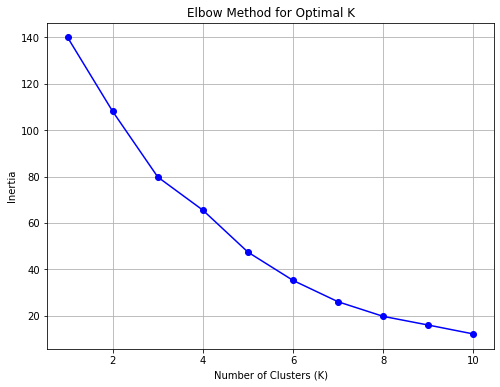

In [52]:
#Elbow Method for K-Means

# Range of cluster numbers to test
k_values = range(1, 11)
inertia_values = []

# Calculate inertia (within-cluster sum of squares) for each K
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(scaled_data)
    inertia_values.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(8, 6))
plt.plot(k_values, inertia_values, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

In [73]:
df_grouped['Cluster'].value_counts()

1    11
0     4
4     4
3     3
2     2
5     2
6     2
Name: Cluster, dtype: int64

In [53]:
# Calculate cluster-level metrics (e.g., mean)
cluster_metrics = df_grouped.groupby('Cluster').agg({'Mean_NatWalkInd': 'mean', 'Greenspace_Pct_mean': 'mean', 'Medical Service Establishments': 'mean',
                                                          'Proportion': 'mean', 'Variance': 'mean'})

In [54]:
cluster_metrics

,Mean_NatWalkInd,Greenspace_Pct_mean,Medical Service Establishments,Proportion,Variance
Cluster,,,,,
0,6.679514,46.272659,5.578981,0.951629,293.391790
1,6.350153,43.618765,6.965781,0.793496,407.824332
2,11.137412,42.409253,5.683314,0.869109,324.171076
3,9.114731,58.079050,6.533334,0.560383,350.093507
4,7.621363,43.281969,5.220177,0.753837,744.643221
5,5.349422,56.643947,9.000000,1.000000,351.236147
6,6.212123,36.603280,2.392000,1.000000,607.668168


In [55]:
# Select only the columns containing metrics to normalize
selected_metrics = cluster_metrics.columns

# Create a StandardScaler instance
scaler = StandardScaler()

# Fit and transform the selected metrics to standardize them
cluster_metrics[selected_metrics] = scaler.fit_transform(cluster_metrics[selected_metrics])

In [60]:
# Select only the columns containing metrics to normalize
selected_metrics = df_grouped.columns

# Create a StandardScaler instance
scaler = StandardScaler()

# Fit and transform the selected metrics to standardize them
df_grouped[selected_metrics] = scaler.fit_transform(df_grouped[selected_metrics])

/opt/tljh/user/lib/python3.7/site-packages/sklearn/utils/extmath.py:847: RuntimeWarning: invalid value encountered in true_divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/opt/tljh/user/lib/python3.7/site-packages/sklearn/utils/extmath.py:689: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = op(x, *args, **kwargs)


In [56]:
cluster_metrics['Sum_Standardized_Metrics'] = cluster_metrics[selected_metrics].sum(axis=1)

In [76]:
cluster_metrics

,Mean_NatWalkInd,Greenspace_Pct_mean,Medical Service Establishments,Proportion,Variance,Sum_Standardized_Metrics
Cluster,,,,,,
0,-0.439188,-0.058948,-0.178807,0.710694,-0.932157,-0.898407
1,-0.616578,-0.423942,0.569147,-0.362626,-0.203888,-1.037888
2,1.961777,-0.590288,-0.122537,0.150591,-0.736272,0.663271
3,0.872388,1.564802,0.335911,-1.944862,-0.571297,0.256941
4,0.068079,-0.470262,-0.372324,-0.631809,1.939687,0.533371
5,-1.155558,1.367430,1.666278,1.039006,-0.564025,2.353130
6,-0.690919,-1.388792,-1.897667,1.039006,1.067953,-1.870419


In [77]:
df_grouped.loc[df_grouped['Cluster'] == 5]

,index,CITY,Medical Service Establishments,res_ratio,bus_ratio,oth_ratio,tot_ratio,STATEFP,COUNTYFP,BLKGRPCE,...,Greenspace_Per_Cap,Mean_NatWalkInd,Greenspace_Pct_mean,Greenspace,bus_ratio_mean,0,1,Proportion,Variance,Cluster
9,9,Greenville,1.322259,-0.732021,2.509155,1.596423,-0.334848,0.0,-0.897805,0.181114,...,0.351334,-1.702074,1.974378,NaN,-1.881184,3.288279,3.478684,1.016465,-0.038399,5
27,27,Youngstown-Warren-Boardman,2.582025,-1.541188,-1.079701,-1.925575,-1.538532,0.0,0.287314,2.067992,...,0.329097,-0.394673,1.361246,NaN,0.239927,3.288279,3.478684,1.016465,-0.397173,5


In [178]:
# Filter the original DataFrame to include only rows with top-ranked clusters
filtered_df = final_matched_df[final_matched_df['Cluster'].isin(top_ranked_clusters.index)]

# Print the unique 'CITY' values for the filtered DataFrame
unique_cities = filtered_df['CITY'].unique()
print(unique_cities)

['Wapakoneta' 'Sandusky' 'Wooster' 'Marion' 'Findlay' 'Mansfield'
 'Portsmouth' 'Springfield' 'Weirton-Steubenville' 'Ashtabula'
 'Mount Vernon' 'Bellefontaine' 'Wheeling' 'Lima' 'Urbana'
 'New Philadelphia-Dover' 'Marietta' 'Van Wert' 'Huntington-Ashland']


In [78]:
pop_df = pd.read_csv('Team-13/oh-zip-codes-data.csv')

In [79]:
pop_df['zip'] = pop_df['zip'].astype(str)

In [80]:
pop_df.head()

,zip,population,city,county
0,45011,72971,Hamilton,Butler
1,43123,66351,Grove City,Franklin
2,44256,64568,Medina,Medina
3,43081,64387,Westerville,Franklin
4,43026,63295,Hilliard,Franklin


In [81]:
final_matched_df_2 = pd.merge(pop_df, final_matched_df_2, on='zip', how='inner')

In [84]:
final_matched_df_2['population']

0         64568
1         64568
2         64568
3         64568
4         64568
          ...  
194218     3086
194219     3086
194220     3086
194221     1723
194222     1723
Name: population, Length: 194223, dtype: int64

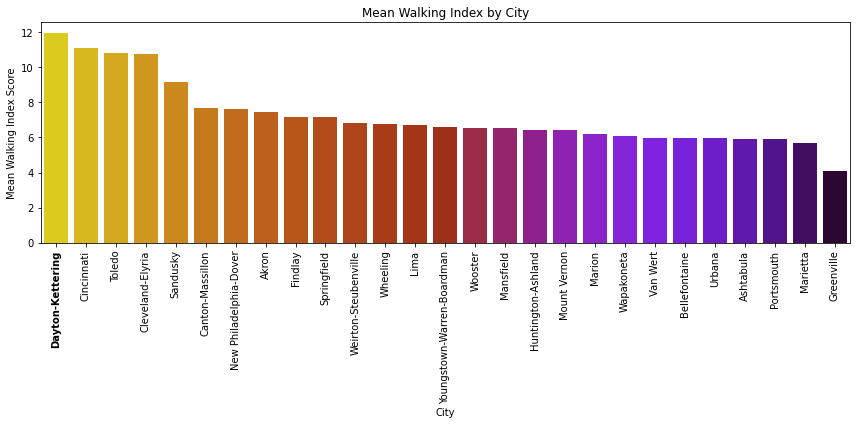

In [179]:
# Create a bar plot using Seaborn
plt.figure(figsize=(12, 6))  # Set the figure size

color_palette = 'gnuplot_r'
df_filtered = final_matched_df_2[final_matched_df_2['CITY'] != 'Columbus']

# Use the 'order' parameter to order cities by their mean 'Mean_NatWalkInd'
ax = sns.barplot(data=df_filtered, x='CITY', y='Mean_NatWalkInd', ci=None,
            order=df_filtered.groupby('CITY')['Mean_NatWalkInd'].mean().sort_values(ascending=False).index,  palette=color_palette)

# Rotate the x-axis labels for better readability
plt.xticks(rotation=90)

# Set plot labels and title
plt.xlabel('City')
plt.ylabel('Mean Walking Index Score')
plt.title('Mean Walking Index by City')

# Bold specific city names in the x-axis labels
bold_city_names = ['Dayton-Kettering']
for label in ax.get_xticklabels():
    if label.get_text() in bold_city_names:
        label.set_weight('bold')

# Show the plot
plt.tight_layout()
plt.show()

In [58]:
# List of selected columns
selected_columns = ['Greenspace_Pct_mean', 'Mean_NatWalkInd', 'Medical Service Establishments', 'Proportion', 'Variance']

# List of selected cities
selected_cities = ['Youngstown-Warren-Boardman', 'Cincinnati', 'Dayton-Kettering']

# Subset the DataFrame to include only the selected cities and columns
subset_df = final_matched_df_2[final_matched_df_2['CITY'].isin(selected_cities)][selected_columns]

# Standardize the data
scaler = StandardScaler()
standardized_data = scaler.fit_transform(subset_df)

# Calculate the standardized sum for each column
column_sums = standardized_data.sum(axis=0)

# Create a DataFrame to store the results
result_df = pd.DataFrame({'Column': selected_columns, 'Standardized Sum': column_sums})

# Print the result DataFrame
print(result_df)

                           Column  Standardized Sum
0             Greenspace_Pct_mean     -1.184333e-10
1                 Mean_NatWalkInd      1.030003e-10
2  Medical Service Establishments     -6.139089e-12
3                      Proportion     -4.547474e-12
4                        Variance     -5.570655e-12


In [59]:
# List of selected columns
selected_columns = ['Greenspace_Pct_mean', 'Mean_NatWalkInd', 'Medical Service Establishments', 'Proportion', 'Variance']

# List of selected cities
selected_cities = ['Youngstown-Warren-Boardman', 'Cincinnati', 'Dayton-Kettering']

# Subset the DataFrame to include only the selected cities and columns
subset_df = final_matched_df_2[final_matched_df_2['CITY'].isin(selected_cities)]

# Group by 'CITY' and calculate the sum of selected columns
sum_by_city = subset_df.groupby('CITY')[selected_columns].sum()

# Print the result DataFrame
print(sum_by_city)

                            Greenspace_Pct_mean  Mean_NatWalkInd  \
CITY                                                               
Cincinnati                         8.477580e+05    225822.058573   
Dayton-Kettering                   1.071830e+06    280966.178044   
Youngstown-Warren-Boardman         1.366849e+03       165.238982   

                            Medical Service Establishments  Proportion  \
CITY                                                                     
Cincinnati                                          114147       17615   
Dayton-Kettering                                    132716       19920   
Youngstown-Warren-Boardman                             250          25   

                                Variance  
CITY                                      
Cincinnati                  6.156501e+06  
Dayton-Kettering            7.683723e+06  
Youngstown-Warren-Boardman  8.166238e+03  


In [73]:
# List of selected cities
selected_cities = ['Youngstown-Warren-Boardman', 'Cincinnati', 'Dayton-Kettering']

# Filter the DataFrame to include only the selected cities
subset_df = df_grouped[df_grouped['CITY'].isin(selected_cities)]

# Assuming you have a column named 'Cluster' in your DataFrame containing cluster labels

# Group the data by 'Cluster' and calculate the mean for each cluster
cluster_means = df_grouped.groupby('Cluster').mean()

# Use the 'transform' function to assign cluster scores to the selected cities
subset_df['Cluster_Score'] = cluster_means.loc[subset_df['Cluster']].values

# Print the DataFrame with cluster scores
print(subset_df[['CITY', 'Cluster', 'Cluster_Score']])

ValueError: Wrong number of items passed 20, placement implies 1

In [75]:
df_grouped[df_grouped['CITY'] == 'Youngstown-Warren-Boardman']

,index,CITY,Medical Service Establishments,res_ratio,bus_ratio,oth_ratio,tot_ratio,STATEFP,COUNTYFP,BLKGRPCE,...,Greenspace_Per_Cap,Mean_NatWalkInd,Greenspace_Pct_mean,Greenspace,bus_ratio_mean,0,1,Proportion,Variance,Cluster
27,27,Youngstown-Warren-Boardman,2.582025,-1.541188,-1.079701,-1.925575,-1.538532,0.0,0.287314,2.067992,...,0.329097,-0.394673,1.361246,NaN,0.239927,3.288279,3.478684,1.016465,-0.397173,5


In [85]:
final_matched_df_2['Medical_Service_Per_Population'] = final_matched_df_2['Medical Service Establishments'] / final_matched_df_2['population']

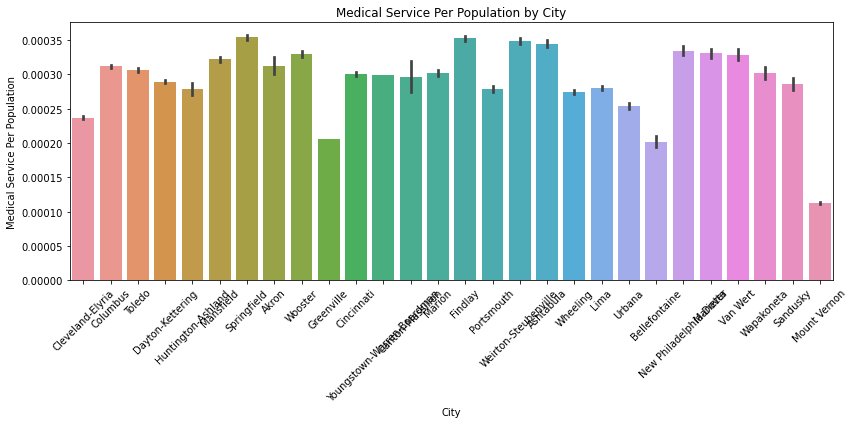

In [86]:
# Create a bar plot using Seaborn
plt.figure(figsize=(12, 6))  # Set the figure size

# Use the 'x' parameter to specify the categorical variable ('CITY' in this case)
# and the 'y' parameter for the numerical variable ('Medical_Service_Per_Population')
sns.barplot(data=final_matched_df_2, x='CITY', y='Medical_Service_Per_Population')

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45)

# Set plot labels and title
plt.xlabel('City')
plt.ylabel('Medical Service Per Population')
plt.title('Medical Service Per Population by City')

# Show the plot
plt.tight_layout()
plt.show()





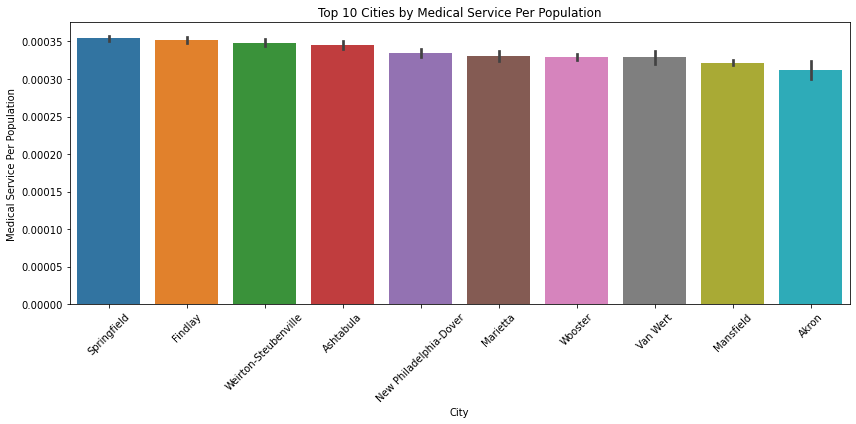

In [90]:
# Get the top 10 cities with the highest 'Medical_Service_Per_Population'
top_cities = final_matched_df_2.groupby('CITY')['Medical_Service_Per_Population'].mean().nlargest(10).index

# Filter the DataFrame to include only the top 10 cities
df_top_10 = final_matched_df_2[final_matched_df_2['CITY'].isin(top_cities)]

# Create a bar plot using Seaborn
plt.figure(figsize=(12, 6))  # Set the figure size

# Use the 'x' parameter to specify the categorical variable ('CITY' in this case)
# and the 'y' parameter for the numerical variable ('Medical_Service_Per_Population')
sns.barplot(data=df_top_10, x='CITY', y='Medical_Service_Per_Population', order=top_cities)

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45)

# Set plot labels and title
plt.xlabel('City')
plt.ylabel('Medical Service Per Population')
plt.title('Top 10 Cities by Medical Service Per Population')

# Show the plot
plt.tight_layout()
plt.show()